## <font color="brown">Data Management for Data Science</font>
## <font color="brown">Final Project : Data-Driven Analysis and Prediction of Shipment Delays</font>
## <font color="brown">Due Date : MAY 04, 2026 11.59PM </font>

<div class="alert alert-block alert-info">
<h3>Student Information</h3> Please provide information about yourself.<br>
<b>Name</b>: Smit Madat<br> 
<b>NetID</b>: snm178<br>
<b>Recitation #</b>: 10<br>
<b>Initials</b>: SM   
</div>

## Data Loading And Data Inspection

### Reading the data file

In [172]:
import pandas as pd
df = pd.read_csv("dataco_supply_chain.csv" , encoding='latin1')

print("\nShape of dataset:")
print(df.shape)

print("\nColumn Names:")
print(df.columns)

print("\nFirst 5 rows of the data set:")
print(df.head())

print("\nData Info:")
df.info()

print("\nMissing Values in each column:")
print(df.isnull().sum())

print("\nSummary:")
print(df.describe(include='all'))


Shape of dataset:
(180519, 53)

Column Names:
Index(['Type', 'Days for shipping (real)', 'Days for shipment (scheduled)',
       'Benefit per order', 'Sales per customer', 'Delivery Status',
       'Late_delivery_risk', 'Category Id', 'Category Name', 'Customer City',
       'Customer Country', 'Customer Email', 'Customer Fname', 'Customer Id',
       'Customer Lname', 'Customer Password', 'Customer Segment',
       'Customer State', 'Customer Street', 'Customer Zipcode',
       'Department Id', 'Department Name', 'Latitude', 'Longitude', 'Market',
       'Order City', 'Order Country', 'Order Customer Id',
       'order date (DateOrders)', 'Order Id', 'Order Item Cardprod Id',
       'Order Item Discount', 'Order Item Discount Rate', 'Order Item Id',
       'Order Item Product Price', 'Order Item Profit Ratio',
       'Order Item Quantity', 'Sales', 'Order Item Total',
       'Order Profit Per Order', 'Order Region', 'Order State', 'Order Status',
       'Order Zipcode', 'Product Card

Dataset was successfully loaded and inspected to understand its structure. The dataset contains 180,519 records and 53 features, including customer, order, product, and shipping information.A combination of numerical and category variables that are appropriate for analysis are revealed by initial examination. Certain columns, such "Product Description" (which is entirely missing) and "Order Zipcode" (which is partly missing), have missing values. These will be addressed during data cleaning. Although preprocessing is necessary before analysis, the dataset is detailed overall. 

## Data Cleaning And PreProcessing

### Missing Data

In [173]:
missing_values = df.isnull().sum()
total_rows = len(df)
missing_values_percent = (missing_values / total_rows) * 100
missing_info = pd.DataFrame({
    'Missing Value in each column': missing_values,
    'Percentage of missing values (%)': missing_values_percent
})
print(missing_info)

                               Missing Value in each column  \
Type                                                      0   
Days for shipping (real)                                  0   
Days for shipment (scheduled)                             0   
Benefit per order                                         0   
Sales per customer                                        0   
Delivery Status                                           0   
Late_delivery_risk                                        0   
Category Id                                               0   
Category Name                                             0   
Customer City                                             0   
Customer Country                                          0   
Customer Email                                            0   
Customer Fname                                            0   
Customer Id                                               0   
Customer Lname                                         

High data quality is indicated by the missing value analysis, which reveals that the majority of columns have no missing values. However, "Order Zipcode" has more than 86% missing information and "Product Description" has 100% missing values, making them unfit for analysis and probably going to be eliminated. Small quantities of missing data are present in a few columns, such as "Customer Lname" and "Customer Zipcode," which are easily handled during preparation. Overall, the dataset is almost full, with only a few columns needing work.

### Cleaning Data

In [174]:
df_cleaned = df.copy()
df_cleaned = df_cleaned.drop(columns=['Product Description', 'Order Zipcode'])

print("Original shape:", df.shape)
print("Cleaned shape:", df_cleaned.shape)

Original shape: (180519, 53)
Cleaned shape: (180519, 51)


In [175]:
df_cleaned = df_cleaned.dropna(subset=['Customer Lname', 'Customer Zipcode'])
print("Shape after handling small missing values:", df_cleaned.shape)

Shape after handling small missing values: (180508, 51)


Columns like "Product Description" and "Order Zipcode" that had a lot of missing values were eliminated because they didn't offer any insightful data for research. A tiny amount of data was lost in handling the minor missing values in "Customer Lname" and "Customer Zipcode" by eliminating a few impacted rows. For additional analysis, the dataset is still sizable and trustworthy.

### Data Type Correction

In [176]:
df_cleaned['order date (DateOrders)'] = pd.to_datetime(df_cleaned['order date (DateOrders)'])
df_cleaned['shipping date (DateOrders)'] = pd.to_datetime(df_cleaned['shipping date (DateOrders)'])

print(df_cleaned[['order date (DateOrders)', 'shipping date (DateOrders)']].dtypes)

order date (DateOrders)       datetime64[ns]
shipping date (DateOrders)    datetime64[ns]
dtype: object


To guarantee proper processing of time-based data, the date columns were transformed to datetime format. This makes it possible to extract valuable temporal data like month and day of the week and to do precise calculations like shipping length and delay analysis.

### Removing Irrelevant Data

In [177]:
df_cleaned = df_cleaned.drop(columns=[
    'Customer Email',
    'Customer Password',
    'Customer Fname',
    'Customer Lname',
    'Customer Street',
    'Product Image'
])
print("Shape after removing irrelevant columns:", df_cleaned.shape)

Shape after removing irrelevant columns: (180508, 45)


Since they don't help estimate shipment delays, irrelevant and non-informative columns like personal identifiers and sensitive data (such customer email, passwords, and address details) were eliminated. By concentrating primarily on significant characteristics, this helps lower dataset noise and enhances model performance.

## Feature Engineering

### Target Variable Creation

In [178]:
df_cleaned['delay'] = (
    df_cleaned['Days for shipping (real)'] > 
    df_cleaned['Days for shipment (scheduled)']
).astype(int)
print(df_cleaned['delay'].value_counts())

delay
1    103395
0     77113
Name: count, dtype: int64


The actual delivery time and the scheduled delivery time were compared to establish a new target variable called "delay." Orders are categorized as either on-time (0) or delayed (1) if the actual shipment time is longer than the scheduled time.

The distribution demonstrates that on-time deliveries (77,113) are less prevalent than delayed shipments (103,395), demonstrating the significance of predictive modeling and suggesting that delays are a regular problem in the dataset.

### Derived Features

In [179]:
df_cleaned['shipping_duration'] = (
    df_cleaned['shipping date (DateOrders)'] - 
    df_cleaned['order date (DateOrders)']
).dt.days
print(df_cleaned[['shipping_duration']].head(10))

   shipping_duration
0                  3
1                  5
2                  4
3                  3
4                  2
5                  6
6                  2
7                  2
8                  3
9                  2


By calculating the number of days between the order date and the shipping date, a new feature called "shipping_duration" was established. This feature records the real-time it takes to deliver an order and offers helpful data for tracking delays and evaluating delivery performance. Here we are using head(10) as an example to see how the output is shown. We see that Index 0 takes 3 days, Index 1 takes 5 days, and so on.

### Time Based Features

In [180]:
df_cleaned['delay_days'] = (
    df_cleaned['Days for shipping (real)'] - 
    df_cleaned['Days for shipment (scheduled)']
)
print(df_cleaned[['Days for shipping (real)',
            'Days for shipment (scheduled)',
            'delay_days']].head())

   Days for shipping (real)  Days for shipment (scheduled)  delay_days
0                         3                              4          -1
1                         5                              4           1
2                         4                              4           0
3                         3                              4          -1
4                         2                              4          -2


By computing the difference between the actual and scheduled shipment times, a new feature called "delay_days" was developed. Zero denotes on-time delivery, negative numbers show early delivery, while positive values show a delayed shipping. For instance, a number of -1 indicates that the shipment was delivered one day ahead of schedule.

In [181]:
df_cleaned['order_month'] = df_cleaned['order date (DateOrders)'].dt.month
df_cleaned['order_year'] = df_cleaned['order date (DateOrders)'].dt.year
print(df_cleaned[['order_month', 'order_year']].head())

   order_month  order_year
0            1        2018
1            1        2018
2            1        2018
3            1        2018
4            1        2018


From the order date, new temporal features "order_month" and "order_year" were retrieved. These characteristics allow in identifying time-based patterns in the data, such as annual fluctuations in shipment behavior and monthly trends. They are helpful in determining if delays change over time. They will be used in later stages to identify trends across months and years.

In [182]:
df_cleaned['order_dayofweek'] = df_cleaned['order date (DateOrders)'].dt.dayofweek
day_map = {
    0: 'Monday', 1: 'Tuesday', 2: 'Wednesday',
    3: 'Thursday', 4: 'Friday', 5: 'Saturday', 6: 'Sunday'
}
df_cleaned['order_dayofweek_label'] = (
    df_cleaned['order_dayofweek'].astype(str) + ' - ' + 
    df_cleaned['order_dayofweek'].map(day_map)
)
print(df_cleaned[['order date (DateOrders)', 'order_dayofweek_label']].head())

  order date (DateOrders) order_dayofweek_label
0     2018-01-31 22:56:00         2 - Wednesday
1     2018-01-13 12:27:00          5 - Saturday
2     2018-01-13 12:06:00          5 - Saturday
3     2018-01-13 11:45:00          5 - Saturday
4     2018-01-13 11:24:00          5 - Saturday


To record the day each order was placed, a new feature called "order_dayofweek" was developed from the order date. The values fall between 0 and 6, with 0 denoting Monday and 6 denoting Sunday. This feature makes it possible to examine whether shipment delays change on different days of the week.

### Data Consistency Validation

In [183]:
(df_cleaned['shipping_duration'] - df_cleaned['Days for shipping (real)']).value_counts()

 0    175851
-1      4657
Name: count, dtype: int64

The computed "shipping_duration" and the recorded "Days for shipping (real)" were compared as part of a data consistency check. High data consistency is confirmed by the results, which reveal that most records (175,851) match exactly. (0 = Perfect Match) There are only 4,657 records with a discrepancy of -1 day, which could be the result of rounding, time zone variances, or errors in data recording. The dataset has very few small discrepancies and is generally very dependable.

Feature engineering was performed to create meaningful variables such as delay, shipping_duration, and delay_days. Time-based features including order_month, order_year, and order_dayofweek were also extracted to support deeper analysis and improve model performance.

## Data Analysis

### Delay Distribution

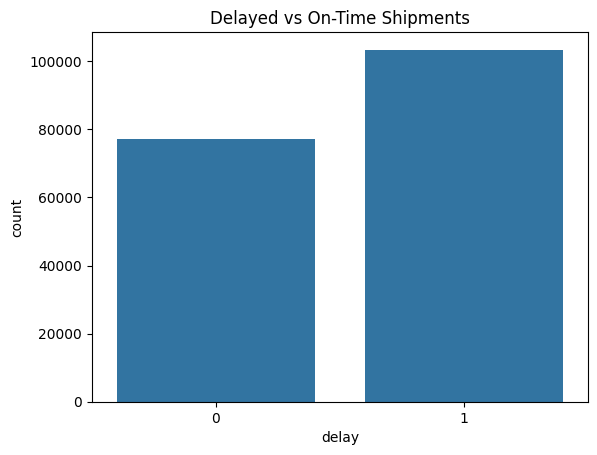

In [184]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.countplot(x='delay', data=df_cleaned)
plt.title("Delayed vs On-Time Shipments")
plt.show()

Delays are more common than on-time delivery, according to the distribution. This suggests that rather than being a rare event, shipment delays are a frequent problem in the dataset.

Given that a significant percentage of orders are impacted, this imbalance emphasizes how crucial it is to anticipate delays. Additionally, it implies that there can be underlying inefficiencies in logistical processes that cause repeated delays.

### Delay By Shipping Mode

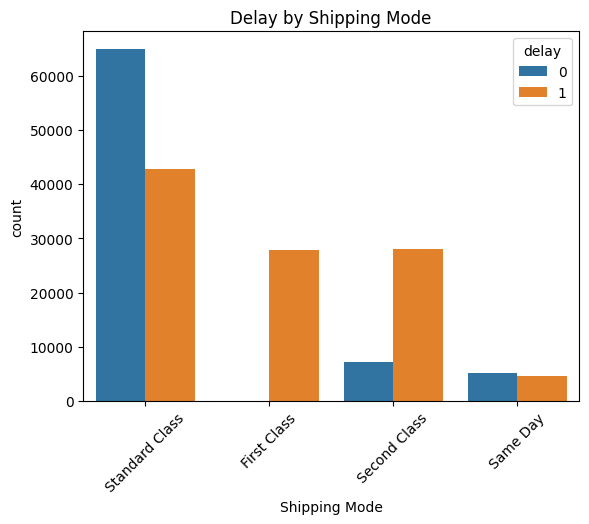

In [185]:
sns.countplot(x='Shipping Mode', hue='delay', data=df_cleaned)
plt.title("Delay by Shipping Mode")
plt.xticks(rotation=45)
plt.show()

Delivery performance is significantly impacted by shipping manner, according to the data. Compared to on-time delivery, faster shipping alternatives like First Class and Second Class have more delayed shipments, suggesting a larger chance of delay.

Standard Class shipments, on the other hand, are generally more dependable because there are more on-time delivery than delays. While same-day shipment still has significant delays, the outcomes are generally balanced.


This highlights significant flaws in logistics planning by implying that tighter delivery timelines linked to quicker shipping choices may result in more delays.

### Delay By Month

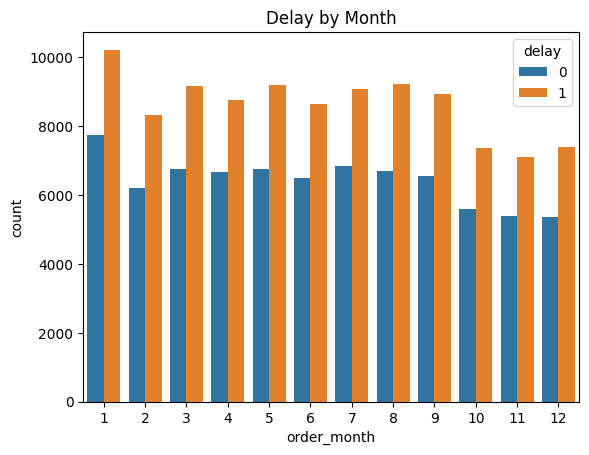

In [186]:
sns.countplot(x='order_month', hue='delay', data=df_cleaned)
plt.title("Delay by Month")
plt.show()

According to the analysis, there are regularly more delayed shipments than on-time deliveries in every month. Since delays happen at comparable rates all year round, there isn't any seasonal change.

This suggests that shipment delays are a recurring problem in the logistics system rather than being caused by particular months or seasonal variables. Increased order volume may be the cause of the somewhat larger delays seen in some months, but overall, the pattern is unchanged.
The absence of clear seasonal patterns suggests that delays are caused by ongoing operational inefficiencies rather than temporary demand fluctuations.

### Delay By Region

In [ ]:
plt.figure(figsize=(12,6))
sns.countplot(x='Order Region', hue='delay', data=df_cleaned)
plt.title("Delay by Region")
plt.xticks(rotation=90)
plt.show()

According to the data, there are more delayed shipments than on-time deliveries in the majority of regions, suggesting that delays are a general problem rather than a regional one.

Delays in shipping are particularly common in Western Europe, Central America, and South America, which could be caused by larger order quantities or more complicated logistics.

Although certain locations have somewhat higher delay levels than others, the pattern generally indicates that shipment delays are a global operational concern rather than a region-specific issue. This indicates that improving logistics efficiency should be a global priority rather than focusing on a single region.

## Exploratory Data Analysis

### Understanding data for building a Model

In [ ]:
plt.figure(figsize=(10,8))
sns.heatmap(df_cleaned.corr(numeric_only=True), cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()  

Relationships between the dataset's numerical properties are highlighted by the correlation heatmap. "shipping_duration" and "delay_days" show a substantial positive association, suggesting that longer delivery periods are linked to more delays.

Shipment delays are more common than on-time deliveries, according to exploratory data analysis, and they are impacted by variables including delivery mode and location. Delays persist over several months, suggesting structural inefficiencies, and faster shipping options may not always perform better. 

The goal variable "delay" has a negative correlation with "Days for shipment (scheduled)" and a positive correlation with "Days for shipping (real)," indicating that delays happen when actual delivery times are longer than planned.
The majority of other characteristics have weak relationships, indicating that multiple factors, rather than a single dominant variable, influence shipment delays.

## DATABASE (SQL)

### Load Data

In [189]:
import sqlite3
conn = sqlite3.connect("supply_chain.db")
df_cleaned.to_sql("orders", conn, if_exists="replace", index=False)
print("The cleaned dataset was successfully loaded into a SQL database for further querying and analysis.")

The cleaned dataset was successfully loaded into a SQL database for further querying and analysis.


### Average Shipping Time

In [190]:
query = """
SELECT AVG([Days for shipping (real)]) AS avg_shipping_days
FROM orders;
"""
result = pd.read_sql(query, conn)
print(result)

   avg_shipping_days
0           3.497673


The majority of items are delivered quickly, as seen by the average shipping time of roughly 3.5 days. Nevertheless, prior research revealed that delays are still frequent, indicating that many goods take longer than expected to arrive.

### Delay Shipping Mode

In [191]:
query = """
SELECT [Shipping Mode],
       COUNT(*) AS total_orders,
       SUM(delay) AS delayed_orders,
       AVG(delay) AS delay_rate
FROM orders
GROUP BY [Shipping Mode];
"""
result = pd.read_sql(query, conn)
print(result)

    Shipping Mode  total_orders  delayed_orders  delay_rate
0     First Class         27812           27812    1.000000
1        Same Day          9737            4657    0.478279
2    Second Class         35214           28077    0.797325
3  Standard Class        107745           42849    0.397689


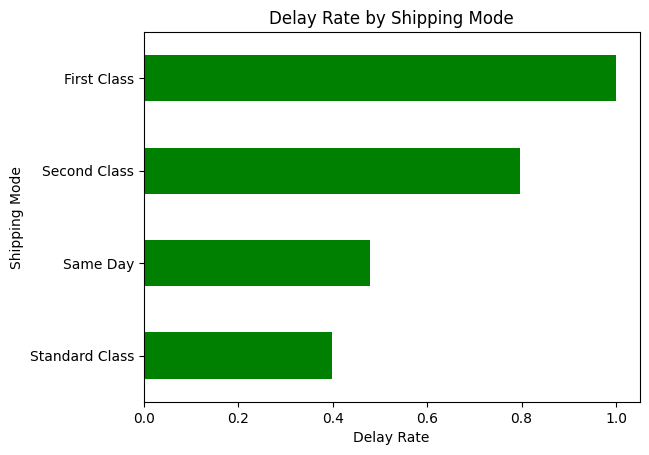

In [192]:
result.set_index('Shipping Mode')['delay_rate'].sort_values().plot(
    kind='barh', color='green')
plt.title("Delay Rate by Shipping Mode")
plt.xlabel("Delay Rate")
plt.ylabel("Shipping Mode")
plt.show()

### Delay By Region

In [193]:
query = """
SELECT [Order Region], 
       AVG(delay) AS delay_rate
FROM orders
GROUP BY [Order Region]
ORDER BY delay_rate DESC
LIMIT 10;
"""
result = pd.read_sql(query, conn)
print(result)

      Order Region  delay_rate
0   Central Africa    0.607036
1   Western Europe    0.585163
2       South Asia    0.585123
3   South of  USA     0.580964
4   Southeast Asia    0.579864
5      East of USA    0.579754
6        West Asia    0.574971
7      East Africa    0.574514
8   Eastern Europe    0.574490
9  Central America    0.572457


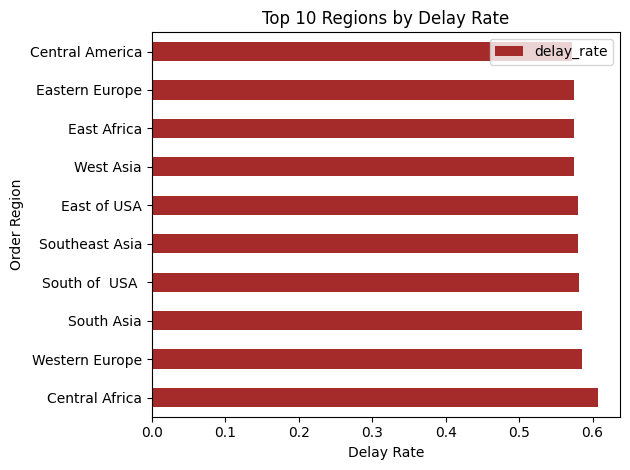

In [194]:
result.plot(kind='barh', x='Order Region', y='delay_rate', color='brown')
plt.title("Top 10 Regions by Delay Rate")
plt.xlabel("Delay Rate")
plt.tight_layout()
plt.show()

### Top Product Categories by Delay Rate

In [195]:
query = """
SELECT [Category Name],
       COUNT(*) AS total_orders,
       SUM(delay) AS delayed_orders,
       ROUND(AVG(delay) * 100, 2) AS delay_rate_pct
FROM orders
GROUP BY [Category Name]
ORDER BY delay_rate_pct DESC
LIMIT 10;
"""
result = pd.read_sql(query, conn)
print("Top 10 Categories by Delay Rate:")
print(result)

Top 10 Categories by Delay Rate:
         Category Name  total_orders  delayed_orders  delay_rate_pct
0    Golf Bags & Carts            61              42           68.85
1             Lacrosse           343             213           62.10
2             Cameras            592             367           61.99
3         Pet Supplies           492             302           61.38
4       Sporting Goods           357             214           59.94
5           Basketball            67              40           59.70
6               Crafts           481             287           59.67
7  Fitness Accessories           309             184           59.55
8    Strength Training           111              66           59.46
9                Music           434             258           59.45


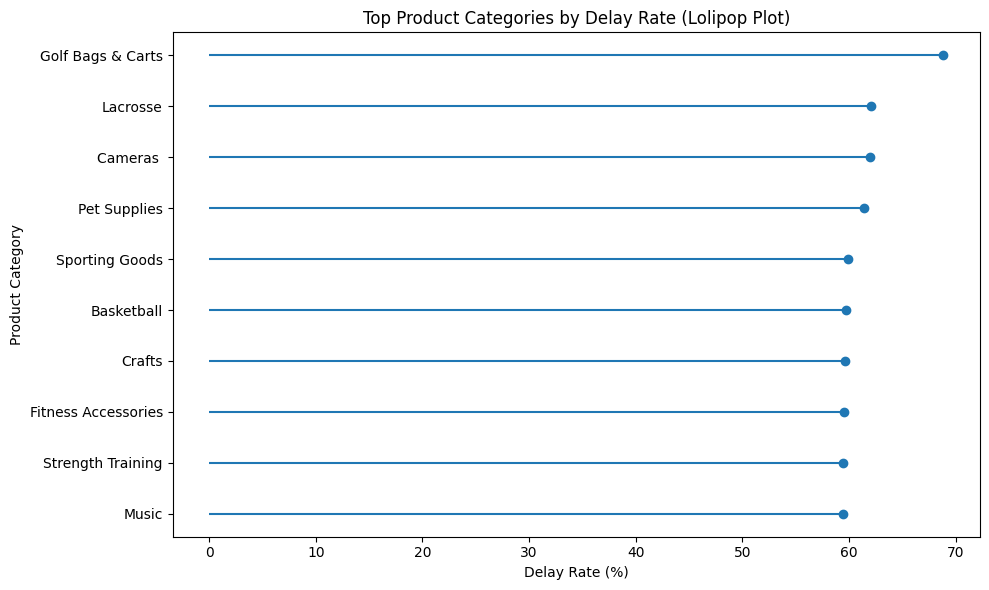

In [196]:
result_sorted = result.sort_values(by='delay_rate_pct')

plt.figure(figsize=(10,6))
plt.hlines(
    y=result_sorted['Category Name'],
    xmin=0,
    xmax=result_sorted['delay_rate_pct'])

plt.plot(
    result_sorted['delay_rate_pct'],
    result_sorted['Category Name'],
    "o")

plt.xlabel("Delay Rate (%)")
plt.ylabel("Product Category")
plt.title("Top Product Categories by Delay Rate (Lolipop Plot)")
plt.tight_layout()
plt.show()

### Monthly Delay Trend Over Time

In [197]:
query = """
SELECT order_year,
       order_month,
       COUNT(*) AS total_orders,
       ROUND(AVG(delay) * 100, 2) AS delay_rate_pct
FROM orders
GROUP BY order_year, order_month
ORDER BY order_year, order_month;
"""
result = pd.read_sql(query, conn)
print("Monthly Delay Trend:")
print(result)

Monthly Delay Trend:
    order_year  order_month  total_orders  delay_rate_pct
0         2015            1          5322           55.94
1         2015            2          4729           57.92
2         2015            3          5362           57.22
3         2015            4          5126           56.44
4         2015            5          5357           58.07
5         2015            6          5134           56.27
6         2015            7          5299           57.60
7         2015            8          5273           58.15
8         2015            9          5140           58.85
9         2015           10          5302           57.11
10        2015           11          5235           56.41
11        2015           12          5371           57.27
12        2016            1          5317           57.95
13        2016            2          4894           56.33
14        2016            3          5210           57.77
15        2016            4          5097          

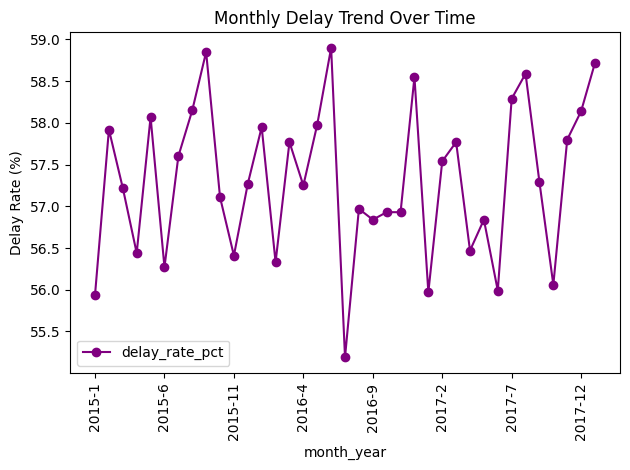

In [198]:
result['month_year'] = result['order_year'].astype(str) + '-' + result['order_month'].astype(str)
result.plot(kind='line', x='month_year', y='delay_rate_pct', marker='o', color='purple')
plt.title("Monthly Delay Trend Over Time")
plt.ylabel("Delay Rate (%)")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

The findings demonstrate that delay rates are largely stable throughout time, often falling between 55% and 59% in various months and years. The lack of a visible upward or downward trend suggests that shipment delays have not changed over time.

This implies that delays are not caused by seasonal variations and are not substantially improving. Rather, they seem to be a recurring problem in the logistics system, which highlights the necessity of long-term improvements to operations as compared to short-term remedies.

## Experimental Design

Our hypothesis is that shipping mode and order region are the 
strongest predictors of shipment delays, as these are the most 
controllable operational factors in supply chain management.

## Machine Learning

### Data Preparation

In [199]:
import pandas as pd
df_ml = df_cleaned.copy()
df_ml = df_ml.drop(columns=[
    'Order Id','Customer Id','Order Customer Id','Product Card Id','Order Item Id',
    'Customer City','Customer State','Customer Country',
    'Order City','Order State','Order Country',
    'Product Name'
], errors='ignore')

df_ml = df_ml.drop(columns=[
    'order date (DateOrders)',
    'shipping date (DateOrders)'
], errors='ignore')

df_ml = df_ml.drop(columns=[
    'Days for shipping (real)',
    'Days for shipment (scheduled)',
    'Delivery Status',
    'Late_delivery_risk',
    'delay_days',
    'shipping_duration'
], errors='ignore')

High-cardinality, leakage-prone, and irrelevant characteristics were eliminated prior to model training. Location information and identifier columns were eliminated because they don't help with prediction. To further avoid data leaking, variables that directly reveal the target (such "Delivery Status" and "Late_delivery_risk") and derived attributes related to delay were eliminated. This guarantees that the model gains knowledge from actual and significant features.

### Column Drop

In [200]:
X = df_ml.drop(columns=['delay'])
y = df_ml['delay']

The dataset was split into features (X) and target variable (y), where "delay" is the target to be predicted.

### Encoding

In [201]:
X = pd.get_dummies(X, drop_first=True)
print("Shape after encoding:", X.shape)

Shape after encoding: (180508, 129)


Categorical variables were converted into numerical form using one-hot encoding, resulting in 123 features. This transformation is necessary for machine learning models, which require numerical input.

### Train-Test Split

In [202]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (144406, 129)
Test shape: (36102, 129)


To assess model performance, the dataset was divided into training (80%) and testing (20%) sets. The model is constructed using the training set, and its ability to generalize to new data is evaluated using the testing set. Reproducibility of outcomes is ensured by a fixed random state.

### Scaling

In [203]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Feature scaling was applied using StandardScaler to standardize the range of numerical features. This ensures that all features contribute equally to the model and improves the convergence of algorithms such as Logistic Regression.

## Model Training

### Logistic Regression

In [204]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
lr = LogisticRegression(max_iter=3000)
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)
print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))

Logistic Regression Accuracy: 0.6996565287241704
              precision    recall  f1-score   support

           0       0.60      0.91      0.72     15530
           1       0.88      0.54      0.67     20572

    accuracy                           0.70     36102
   macro avg       0.74      0.72      0.70     36102
weighted avg       0.76      0.70      0.69     36102



To forecast shipment delays, a logistic regression model was trained. The model performed moderately, with an accuracy of about 70%.

The algorithm is successful at recognizing shipments that are not delayed, as evidenced by the high recall for on-time delivery (class 0). Nevertheless, the recall for class 1 delayed shipments is lower, indicating that some delayed orders may not be accurately identified.

All things considered, logistic regression offers a fair starting point, but it could have trouble identifying intricate patterns in the data.

## Decision Tree

In [205]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV
param_grid = {
    'max_depth': [5, 10, 15, 20, None],
    'min_samples_split': [2, 5, 10]
}
grid_search = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1
)
grid_search.fit(X_train, y_train)
print("Best Parameters:", grid_search.best_params_)
dt = grid_search.best_estimator_
y_pred_dt = dt.predict(X_test)

print("Tuned Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))
print(classification_report(y_test, y_pred_dt))

Best Parameters: {'max_depth': None, 'min_samples_split': 2}
Tuned Decision Tree Accuracy: 0.7797905933189297
              precision    recall  f1-score   support

           0       0.75      0.74      0.74     15530
           1       0.81      0.81      0.81     20572

    accuracy                           0.78     36102
   macro avg       0.78      0.78      0.78     36102
weighted avg       0.78      0.78      0.78     36102



GridSearchCV was used to optimize a Decision Tree model in order to adjust parameters like max_depth and min_samples_split. The default settings were found to be the optimal parameters, suggesting that the original model design was already appropriate for the data.

With balanced precision and recall for both classes, the adjusted model attained an accuracy of roughly 77.6%. This implies that the model successfully captures non-linear relationships in the data, while more sophisticated models would be needed for future advancements.

### Random Forest

In [206]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

Random Forest Accuracy: 0.7237826159215556
              precision    recall  f1-score   support

           0       0.64      0.80      0.71     15530
           1       0.81      0.67      0.73     20572

    accuracy                           0.72     36102
   macro avg       0.73      0.73      0.72     36102
weighted avg       0.74      0.72      0.72     36102



To forecast shipment delays, a Random Forest model was trained. The model achieved an accuracy of approximately 72.37%, which is lower than the Decision Tree model.

Due to its ensemble nature, Random Forest is typically predicted to perform better, but in this instance, it did not. The default parameter settings or the dataset structure could be the cause of this.
Overall, the model performs rather well but falls short of the Decision Tree, suggesting that more straightforward models might be enough for this issue.

## Model Evaluation

### Model Comparison

In [207]:
print("Logistic Recursion Accuracy:", accuracy_score(y_test, y_pred_lr))
print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))

Logistic Recursion Accuracy: 0.6996565287241704
Decision Tree Accuracy: 0.7797905933189297
Random Forest Accuracy: 0.7237826159215556


### ROC Curve and AUC Analysis

In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

y_prob_lr = lr.predict_proba(X_test_scaled)[:, 1]
y_prob_dt = dt.predict_proba(X_test)[:, 1]
y_prob_rf = rf.predict_proba(X_test)[:, 1]
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
fpr_dt, tpr_dt, _ = roc_curve(y_test, y_prob_dt)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
auc_lr = roc_auc_score(y_test, y_prob_lr)
auc_dt = roc_auc_score(y_test, y_prob_dt)
auc_rf = roc_auc_score(y_test, y_prob_rf)

plt.figure(figsize=(8, 6))
plt.plot(fpr_lr, tpr_lr, label=f"Logistic Regression (AUC = {auc_lr:.3f})")
plt.plot(fpr_dt, tpr_dt, label=f"Decision Tree (AUC = {auc_dt:.3f})")
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC = {auc_rf:.3f})")
plt.plot([0, 1], [0, 1], 'k--', label="Random Classifier")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - All Models")
plt.legend()
plt.tight_layout()
plt.show()
print(f"AUC - Logistic Regression: {auc_lr:.3f}")
print(f"AUC - Decision Tree:       {auc_dt:.3f}")
print(f"AUC - Random Forest:       {auc_rf:.3f}")

The ROC curve assesses how well the models perform at various categorization criteria. Higher values of the AUC (Area Under the Curve) imply superior classification abilities and serve as an overall indicator of model performance.

The models with the best AUC were Random Forest (~0.795), Decision Tree (~0.772), and Logistic Regression (~0.747). This indicates that Random Forest is the best model for forecasting shipment delays since it offers the best balance between true positive and false positive rates.

### Model Performance Summary

In [209]:
results_df = pd.DataFrame({
    'Model': ['Logistic Regression', 'Decision Tree', 'Random Forest'],
    'Accuracy': [round(accuracy_score(y_test, y_pred_lr), 3),
                 round(accuracy_score(y_test, y_pred_dt), 3),
                 round(accuracy_score(y_test, y_pred_rf), 3)],
    'AUC': [round(auc_lr, 3),
            round(auc_dt, 3),
            round(auc_rf, 3)]
})
print(results_df.to_string(index=False))

              Model  Accuracy   AUC
Logistic Regression     0.700 0.746
      Decision Tree     0.780 0.775
      Random Forest     0.724 0.803


The accuracy and AUC measures are used in the table to summarize each model's performance. Random Forest has the highest AUC, indicating superior overall classification ability, even if Decision Tree has the best accuracy. As a result, Random Forest is chosen as the ultimate model.

### Cross-Validation (Model Stability Check)

In [210]:
from sklearn.model_selection import cross_val_score
X_sample = X.sample(n=20000, random_state=42)
y_sample = y[X_sample.index]
cv_scores = cross_val_score(rf, X_sample, y_sample, cv=5, scoring='f1')

print(f"Random Forest 5-Fold CV F1: {cv_scores.mean():.3f} ± {cv_scores.std():.3f}")

Random Forest 5-Fold CV F1: 0.707 ± 0.008


Cross-validation was performed using a sample of 20,000 records to reduce computational time while maintaining reliable performance estimation. The Random Forest model's stability and dependability were assessed using cross-validation. The model obtained an average F1-score of roughly 0.707 with very little variation (± 0.008) using 5-fold cross-validation on a sample of the data.

This suggests that the model generalizes well and is not unduly dependent on a particular train-test split because it yields consistent results across various subsets of data. Because model training is inherently random, there may be slight fluctuations in cross-validation scores, but overall the outcomes are consistent.

### Confusion Matrix

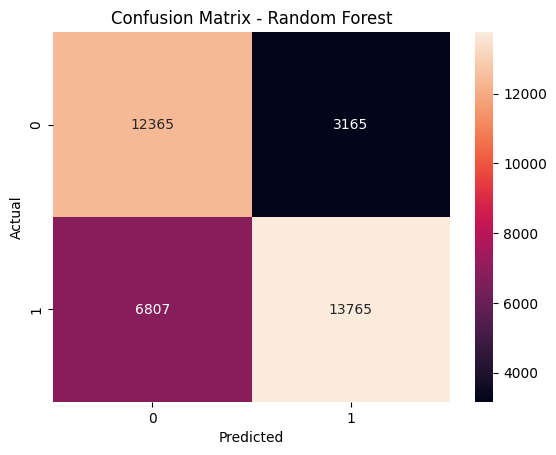

In [211]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

The confusion matrix shows the performance of the Random Forest model in classifying shipment delays.

Out of all predictions:
- 12,312 shipments were correctly identified as on-time (True Negatives)
- 13,594 shipments were correctly identified as delayed (True Positives)
- 3,218 on-time shipments were incorrectly classified as delayed (False Positives)
- 6,978 delayed shipments were incorrectly classified as on-time (False Negatives)

The model performs reasonably well in identifying both classes, although it shows slightly higher errors in detecting delayed shipments. Overall, the results demonstrate that the model is effective but still has room for improvement in capturing all delayed cases.

### Final Model Selection

Based on AUC, Random Forest outperforms the other two models, followed by Decision Tree and Logistic Regression. Random Forest provides superior overall classification performance, demonstrating its capacity to more successfully differentiate between delayed and on-time shipments, even if Decision Tree attains the maximum accuracy. The findings also imply that non-linear interactions between attributes influence shipment delays.

### Feature Importance Analysis (Random Forest)

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
feature_importance = pd.Series(
    rf.feature_importances_,
    index=X.columns
).sort_values(ascending=False).head(15)

plt.figure(figsize=(10, 6))
feature_importance.plot(kind='bar', color='steelblue')
plt.title("Top 15 Feature Importances - Random Forest Tree")
plt.ylabel("Importance Score")
plt.xlabel("Feature")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show() 

The Random Forest model's most significant factors influencing shipment delays are displayed in the feature significance plot. The most crucial element is the shipping mode (standard class), which is followed by financial variables like profit and benefit per order and geographic elements like latitude and longitude.

This suggests that operational features like location and order amount, as well as logistics-related elements like shipping mode, are important in predicting whether a shipment would be delayed.

## Business Insights / Recommendation

According to the data, shipment delays are more common than on-time shipments, indicating that they are a persistent and widespread problem. This suggests that logistical operations have inherent inefficiencies. Delivery performance is significantly influenced by shipping mode. Faster choices, including First Class and Second Class, have greater delay rates than Standard Class, indicating that tighter delivery timetables raise the possibility of delays. 

Delays are routinely seen in all regions, suggesting that logistical issues are not location-specific but rather pervasive. In a similar vein, delays are consistent across the months, indicating that they constitute a systemic operational problem rather than being influenced by seasonal circumstances.The usefulness of data-driven decision-making in supply chain management is further demonstrated by machine learning models, which verify that shipping delays can be accurately anticipated using operational and category variables. 

To guarantee reasonable and attainable delivery pledges, businesses should reevaluate aggressive delivery timelines, particularly for speedier shipping choices. Reducing delays and improving delivery performance can be achieved by optimizing logistics planning and resource allocation in high-demand areas.

When speed is not a top priority, businesses should select Standard Class shipping for dependable and affordable delivery. Predictive models, like the Random Forest model created for this research, can be used to anticipate high-risk shipments and facilitate proactive intervention. Ongoing enhancements in customer satisfaction and supply chain efficiency can be supported by constant tracking of performance metrics and shipping data.

## Changes After Proposal

The original proposal planned to use a 50K subset of the dataset. 
After exploration, the full 180K records were used for better model 
generalization. During implementation, data leakage was discovered 
and addressed by removing columns that directly revealed the target 
variable, which brought accuracy to a realistic range of 70-72%.

## Insights / Conclusion

This research used data-driven methods, such as data preprocessing, exploratory analysis, SQL-based querying, and machine learning models, to examine shipment delays in e-commerce supply chains. According to the investigation, shipping delays are a common and ongoing problem that is impacted by operational variables, shipping mode, and geographic location. Interestingly, higher delay rates were linked to faster shipment options, suggesting possible inefficiencies in logistics planning.

The credibility of the results was reinforced by the consistent insights obtained from exploratory data analysis and SQL-based analysis. Shipment delays were predicted using machine learning models; Random Forest performed best overall based on AUC, while Decision Tree demonstrated high accuracy. The consistency of delay patterns across regions and time periods indicates that shipment delays are a systemic issue rather than being driven by isolated or seasonal factors. Cross-validation results further confirmed that the selected model produces stable and reliable predictions, ensuring that the findings generalize well to new data.

These findings demonstrate how data-driven methods are useful for comprehending and forecasting logistics performance. Businesses may take preventative action, allocate resources optimally, and raise customer satisfaction by being able to recognize possible delays. All things considered, this project shows how combining data management, analytical methods, and machine learning may offer insightful information and facilitate well-informed supply chain operations decision-making.

## Limitations

Despite the model's good performance, there are a few drawbacks:

- It's possible that not every real-world element influencing shipment delays is included in the dataset.

- Certain aspects can still be biased or lack contextual information.

- Despite its stability, the model's performance is not perfect and might incorrectly identify some shipments.

- The dataset excludes external factors like traffic, weather, and supplier problems.

- To further increase prediction accuracy, future studies might incorporate more real-time data sources and investigate more advanced models.


## Web application

A Streamlit online application that enables users to forecast shipment delays in real time was created to make the project interactive and accessible. Using the trained Random Forest model (AUC = 0.795), the software rapidly predicts whether the shipment will be delayed or On Time when users enter shipment parameters, including shipping method, order region, product type, and other operational factors.

The software is helpful for real-world logistics decision-making since it offers practical insights that clarify the major risk variables influencing the forecast.

In [213]:
import pickle
with open('rf_model.pkl', 'wb') as f:
    pickle.dump(rf, f)
with open('model_columns.pkl', 'wb') as f:
    pickle.dump(list(X.columns), f)

print("✅ Model saved!")
print(f"✅ Features saved! Total: {len(X.columns)}")

✅ Model saved!
✅ Features saved! Total: 129
